# Análise Long Neck NENO — Ambev Case
### Visualização de dados de demanda, produção, estoque e custos logísticos
Este notebook explora o dataset do case Ambev x Insper, focado no crescimento de cervejas premium em embalagem Long Neck na região Nordeste (NENO).


In [60]:
# Importações e configuração visual padrão
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11
})

# Paleta customizada Ambev
AMBEV_YELLOW = '#FFB800'
AMBEV_DARK = '#1A1A1A'
AMBEV_BLUE = '#4169E1'
AMBEV_RED = '#C0392B'
AMBEV_GREEN = '#27AE60'


## 1. Carregamento dos Dados
Leitura de todas as abas do arquivo Excel convertido (.xlsx).

In [61]:
# Carrega todas as abas relevantes do arquivo
file_path = '/Users/gustavopacheco/Downloads/Analise_LongNeck_OTIMIZADO.xlsx'

cenario_br = pd.read_excel(file_path, sheet_name='Cenário atual BR', header=None)
custos = pd.read_excel(file_path, sheet_name='Custos de transferência', header=None)
producao_pcp = pd.read_excel(file_path, sheet_name='Produção PCP', header=None)
transf_prog = pd.read_excel(file_path, sheet_name='Transferências Programadas', header=None)
cenario_div = pd.read_excel(file_path, sheet_name='Cenário Divulgado', header=None)
cenario_novo = pd.read_excel(file_path, sheet_name='Cenário com Nova Demanda', header=None)

print("Abas carregadas com sucesso!")
for name, df in [('Cenário BR', cenario_br), ('Custos', custos), 
                  ('Produção PCP', producao_pcp), ('Transf. Prog.', transf_prog),
                  ('Cenário Divulgado', cenario_div), ('Cenário Nova Demanda', cenario_novo)]:
    print(f"  {name}: {df.shape[0]} linhas x {df.shape[1]} colunas")


Abas carregadas com sucesso!
  Cenário BR: 25 linhas x 24 colunas
  Custos: 23 linhas x 5 colunas
  Produção PCP: 16 linhas x 10 colunas
  Transf. Prog.: 8 linhas x 11 colunas
  Cenário Divulgado: 49 linhas x 48 colunas
  Cenário Nova Demanda: 49 linhas x 48 colunas


## 2. Evolução Histórica de Vendas Long Neck NENO
Crescimento anual do volume vendido de Long Neck no Nordeste (2021–2025), evidenciando a tendência de alta consistente.

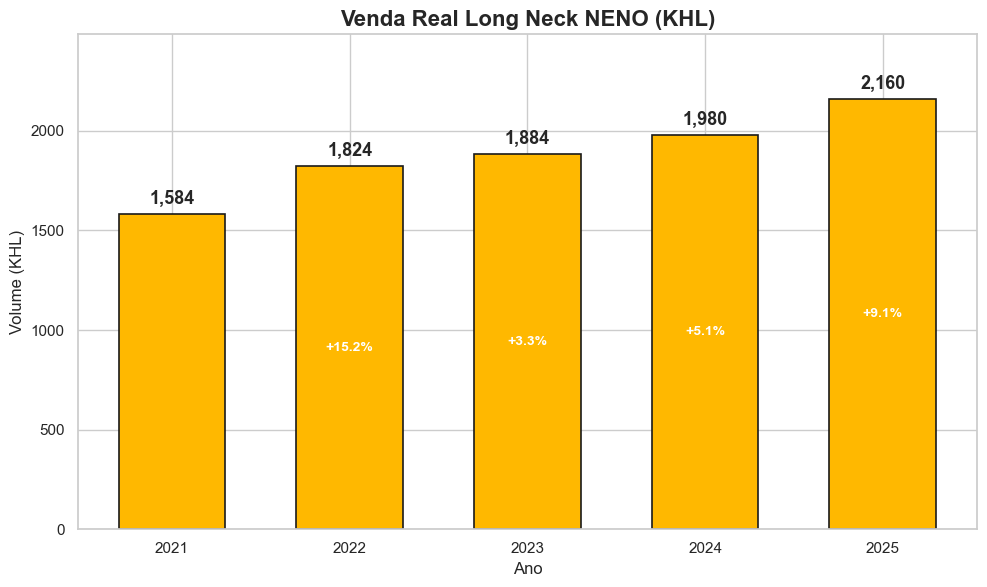

In [62]:
# Dados históricos de venda LN NENO extraídos da apresentação
anos = [2021, 2022, 2023, 2024, 2025]
vendas_khl = [1584, 1824, 1884, 1980, 2160]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(anos, vendas_khl, color=AMBEV_YELLOW, edgecolor=AMBEV_DARK, linewidth=1.2, width=0.6)

# Anotações de valor e crescimento YoY
for i, (bar, v) in enumerate(zip(bars, vendas_khl)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
            f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=13)
    if i > 0:
        growth = (vendas_khl[i] - vendas_khl[i-1]) / vendas_khl[i-1] * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2,
                f'+{growth:.1f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

ax.set_title('Venda Real Long Neck NENO (KHL)', fontsize=16, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Volume (KHL)')
ax.set_ylim(0, max(vendas_khl) * 1.15)
ax.set_xticks(anos)
plt.tight_layout()
plt.show()


## 3. Demanda Mensal LN NENO — 1º Semestre 2026
Projeção de demanda mensal, mostrando sazonalidade com queda em março e pico em janeiro/julho.

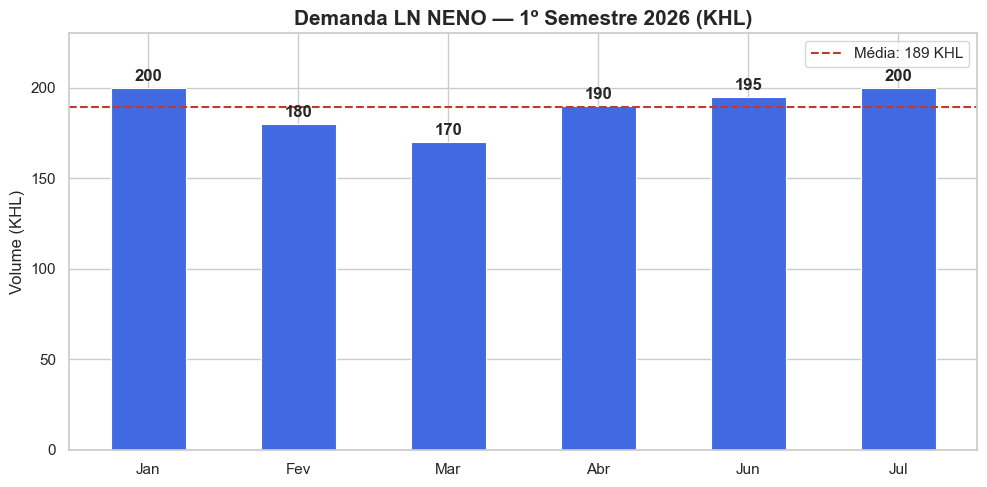

In [63]:
# Demanda mensal projetada para 1S 2026
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Jun', 'Jul']
demanda = [200, 180, 170, 190, 195, 200]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(meses, demanda, color=AMBEV_BLUE, edgecolor='white', linewidth=0.8, width=0.5)
ax.axhline(y=np.mean(demanda), color=AMBEV_RED, linestyle='--', linewidth=1.5, label=f'Média: {np.mean(demanda):.0f} KHL')

for bar, v in zip(bars, demanda):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{v}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Demanda LN NENO — 1º Semestre 2026 (KHL)', fontsize=15, fontweight='bold')
ax.set_ylabel('Volume (KHL)')
ax.set_ylim(0, 230)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 4. Demanda por Região — Cenário Brasil (Janeiro)
Distribuição da demanda total de Long Neck entre as regionais do Brasil, destacando o peso do NENO.

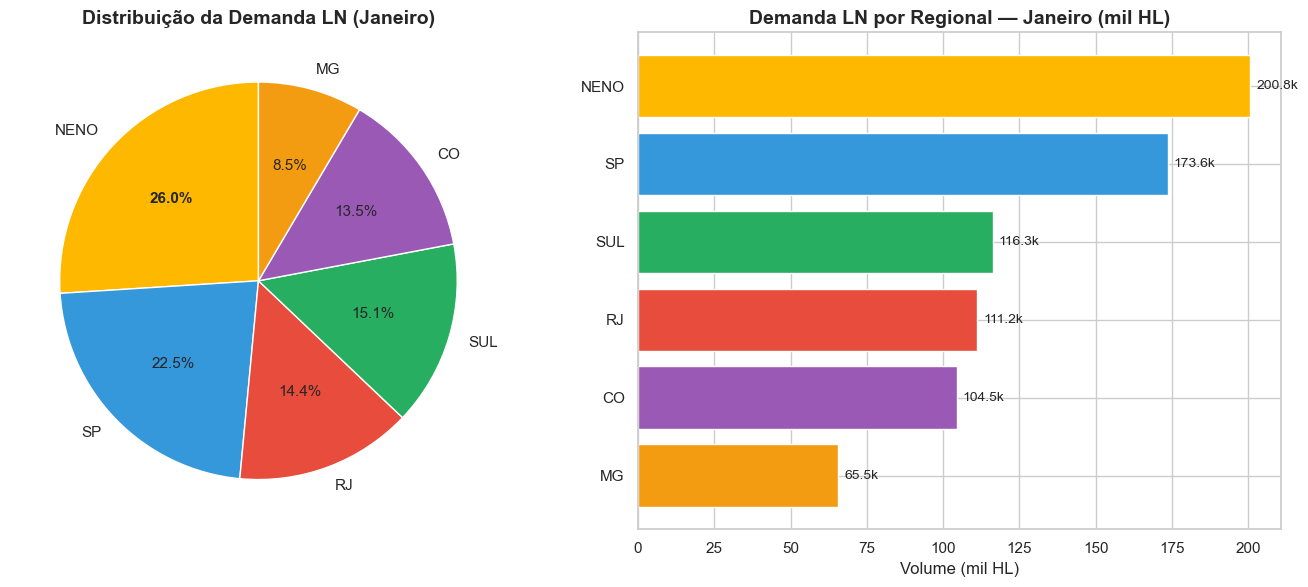

In [64]:
# Dados do Cenário atual BR — Demanda Janeiro
regioes = ['NENO', 'SP', 'RJ', 'SUL', 'CO', 'MG']
demanda_jan = [200754.27, 173637.41, 111219.41, 116261.41, 104493.31, 65538.32]

colors = [AMBEV_YELLOW, '#3498DB', '#E74C3C', AMBEV_GREEN, '#9B59B6', '#F39C12']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de pizza
wedges, texts, autotexts = ax1.pie(demanda_jan, labels=regioes, autopct='%1.1f%%',
                                     colors=colors, startangle=90, textprops={'fontsize': 11})
autotexts[0].set_fontweight('bold')
ax1.set_title('Distribuição da Demanda LN (Janeiro)', fontsize=14, fontweight='bold')

# Gráfico de barras horizontal
sorted_idx = np.argsort(demanda_jan)
ax2.barh([regioes[i] for i in sorted_idx], [demanda_jan[i]/1000 for i in sorted_idx], 
         color=[colors[i] for i in sorted_idx], edgecolor='white')
ax2.set_xlabel('Volume (mil HL)')
ax2.set_title('Demanda LN por Regional — Janeiro (mil HL)', fontsize=14, fontweight='bold')

for i, idx in enumerate(sorted_idx):
    ax2.text(demanda_jan[idx]/1000 + 2, i, f'{demanda_jan[idx]/1000:.1f}k', va='center', fontsize=10)

plt.tight_layout()
plt.show()


## 5. Plano de Produção PCP — Fevereiro 2026
Alocação da produção por SKU nas duas linhas do Nordeste (AQ541 em Aquiraz/CE e NS541 em Pernambuco) ao longo das 4 semanas de fevereiro.

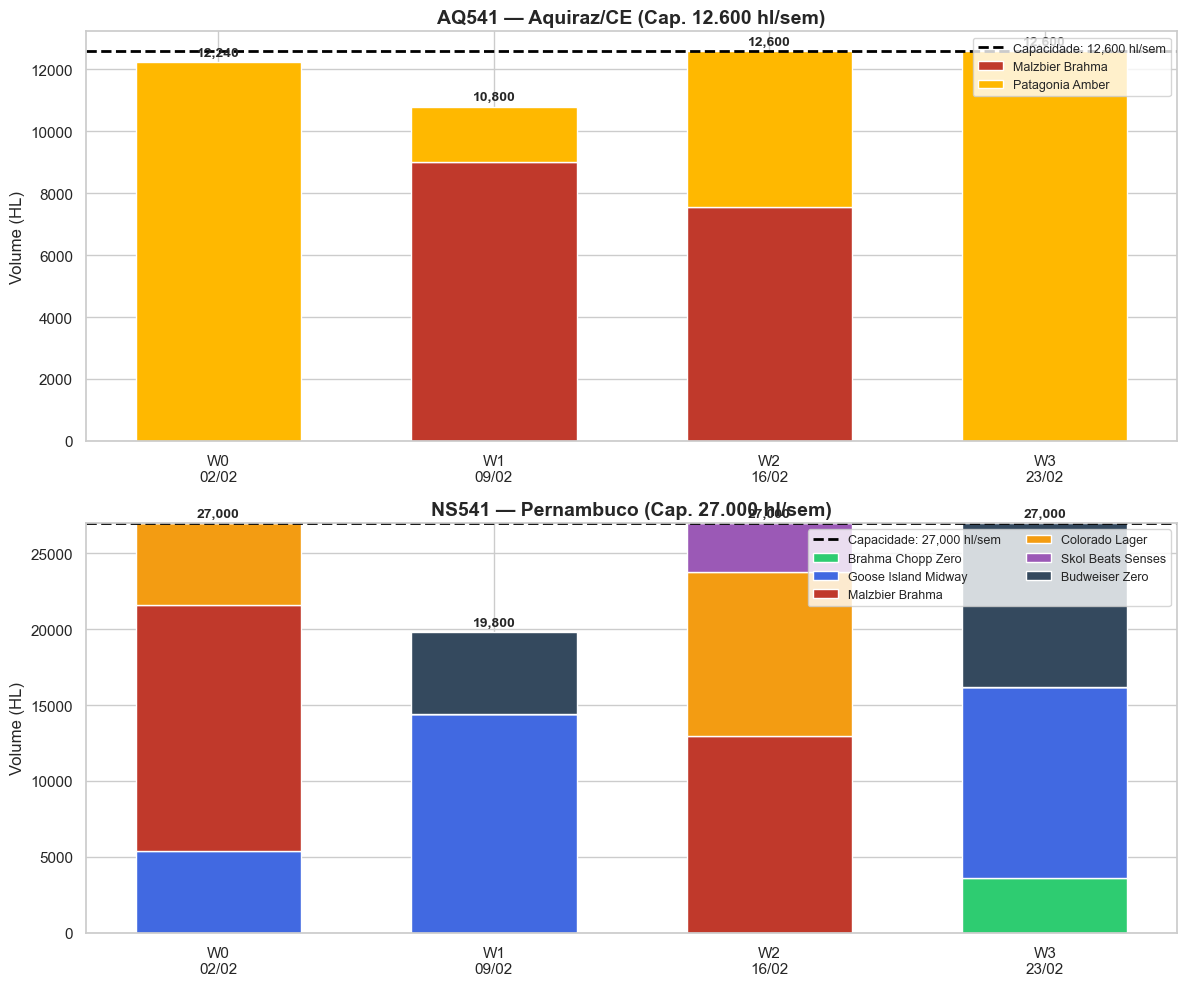

In [65]:
# Produção PCP - Linha AQ541 (Aquiraz/CE) — Capacidade: 12.600 hl/semana
semanas = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']

# AQ541 SKUs
aq_malzbier  = [0, 9000, 7560, 0]
aq_patagonia = [12240, 1800, 5040, 12600]
aq_colorado  = [0, 0, 0, 0]
aq_cap = 12600

# NS541 SKUs
ns_brahma_zero = [0, 0, 0, 3600]
ns_goose       = [5400, 14400, 0, 12600]
ns_malzbier    = [16200, 0, 12960, 0]
ns_colorado    = [5400, 0, 10800, 0]
ns_skol        = [0, 0, 3240, 0]
ns_bud_zero    = [0, 5400, 0, 10800]
ns_cap = 27000

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# AQ541
x = np.arange(len(semanas))
w = 0.6
ax1.bar(x, aq_malzbier, w, label='Malzbier Brahma', color=AMBEV_RED)
ax1.bar(x, aq_patagonia, w, bottom=aq_malzbier, label='Patagonia Amber', color=AMBEV_YELLOW)
ax1.axhline(y=aq_cap, color='black', linestyle='--', linewidth=2, label=f'Capacidade: {aq_cap:,} hl/sem')
ax1.set_xticks(x)
ax1.set_xticklabels(semanas)
ax1.set_ylabel('Volume (HL)')
ax1.set_title('AQ541 — Aquiraz/CE (Cap. 12.600 hl/sem)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)

# Mostrar total
for i in range(4):
    total = aq_malzbier[i] + aq_patagonia[i]
    ax1.text(i, total + 200, f'{total:,.0f}', ha='center', fontweight='bold', fontsize=10)

# NS541
bottom1 = ns_brahma_zero
bottom2 = [a+b for a,b in zip(bottom1, ns_goose)]
bottom3 = [a+b for a,b in zip(bottom2, ns_malzbier)]
bottom4 = [a+b for a,b in zip(bottom3, ns_colorado)]
bottom5 = [a+b for a,b in zip(bottom4, ns_skol)]

ax2.bar(x, ns_brahma_zero, w, label='Brahma Chopp Zero', color='#2ECC71')
ax2.bar(x, ns_goose, w, bottom=bottom1, label='Goose Island Midway', color=AMBEV_BLUE)
ax2.bar(x, ns_malzbier, w, bottom=bottom2, label='Malzbier Brahma', color=AMBEV_RED)
ax2.bar(x, ns_colorado, w, bottom=bottom3, label='Colorado Lager', color='#F39C12')
ax2.bar(x, ns_skol, w, bottom=bottom4, label='Skol Beats Senses', color='#9B59B6')
ax2.bar(x, ns_bud_zero, w, bottom=bottom5, label='Budweiser Zero', color='#34495E')
ax2.axhline(y=ns_cap, color='black', linestyle='--', linewidth=2, label=f'Capacidade: {ns_cap:,} hl/sem')
ax2.set_xticks(x)
ax2.set_xticklabels(semanas)
ax2.set_ylabel('Volume (HL)')
ax2.set_title('NS541 — Pernambuco (Cap. 27.000 hl/sem)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9, ncol=2)

for i in range(4):
    total = ns_brahma_zero[i]+ns_goose[i]+ns_malzbier[i]+ns_colorado[i]+ns_skol[i]+ns_bud_zero[i]
    ax2.text(i, total + 400, f'{total:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


## 6. Custos de Transferência e Produção
Comparação entre custo de transferência (SP → NE via cabotagem), MACO (margem de contribuição na produção interna) e custo de produção por SKU.

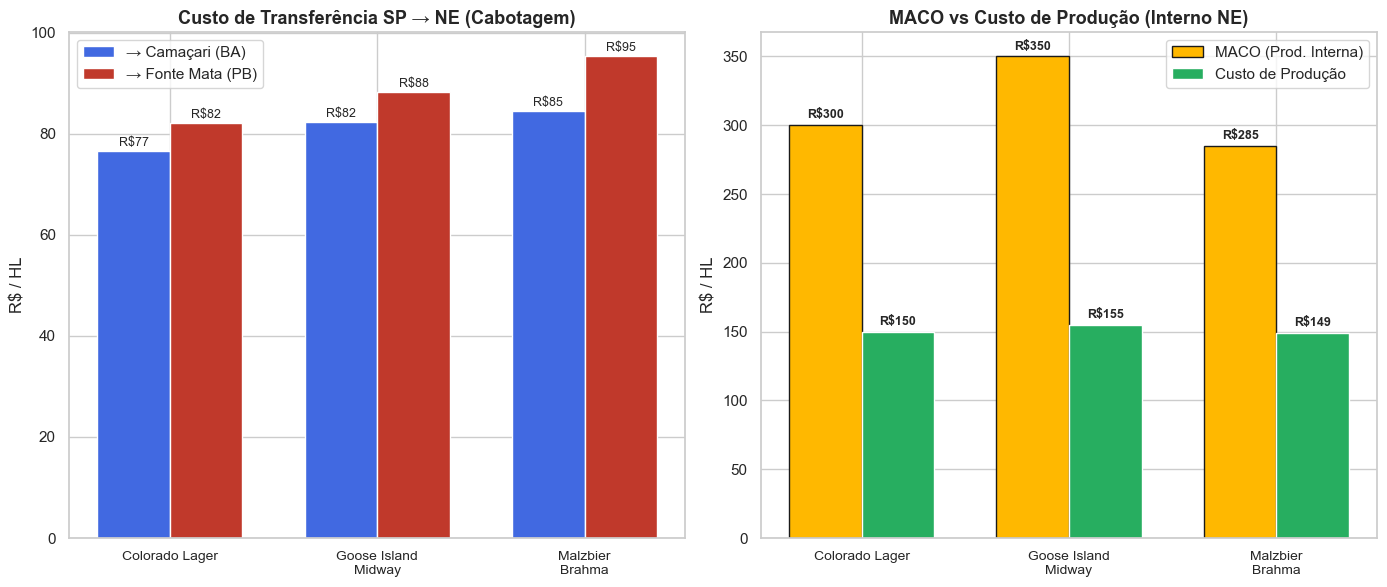

In [66]:
# Dados de custos
skus_short = ['Colorado Lager', 'Goose Island\nMidway', 'Malzbier\nBrahma']

# Custos de transferência (média entre destinos para simplificar)
transf_camacari = [76.59, 82.40, 84.58]
transf_fonte_mata = [82.08, 88.30, 95.33]

maco = [300, 350, 285]
custo_prod = [150, 155, 149]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Custos de transferência
x = np.arange(len(skus_short))
w = 0.35
ax1.bar(x - w/2, transf_camacari, w, label='→ Camaçari (BA)', color=AMBEV_BLUE)
ax1.bar(x + w/2, transf_fonte_mata, w, label='→ Fonte Mata (PB)', color=AMBEV_RED)
ax1.set_xticks(x)
ax1.set_xticklabels(skus_short, fontsize=10)
ax1.set_ylabel('R$ / HL')
ax1.set_title('Custo de Transferência SP → NE (Cabotagem)', fontsize=13, fontweight='bold')
ax1.legend()

for i in range(3):
    ax1.text(i - w/2, transf_camacari[i] + 1, f'R${transf_camacari[i]:.0f}', ha='center', fontsize=9)
    ax1.text(i + w/2, transf_fonte_mata[i] + 1, f'R${transf_fonte_mata[i]:.0f}', ha='center', fontsize=9)

# MACO vs Custo de Produção
ax2.bar(x - w/2, maco, w, label='MACO (Prod. Interna)', color=AMBEV_YELLOW, edgecolor=AMBEV_DARK)
ax2.bar(x + w/2, custo_prod, w, label='Custo de Produção', color=AMBEV_GREEN)
ax2.set_xticks(x)
ax2.set_xticklabels(skus_short, fontsize=10)
ax2.set_ylabel('R$ / HL')
ax2.set_title('MACO vs Custo de Produção (Interno NE)', fontsize=13, fontweight='bold')
ax2.legend()

for i in range(3):
    ax2.text(i - w/2, maco[i] + 5, f'R${maco[i]}', ha='center', fontsize=9, fontweight='bold')
    ax2.text(i + w/2, custo_prod[i] + 5, f'R${custo_prod[i]}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 7. Impacto da Nova Demanda — Malzbier Brahma
Comparação da demanda semanal de Malzbier Brahma no cenário original versus o cenário com aumento de 30%, por sub-região do NENO.

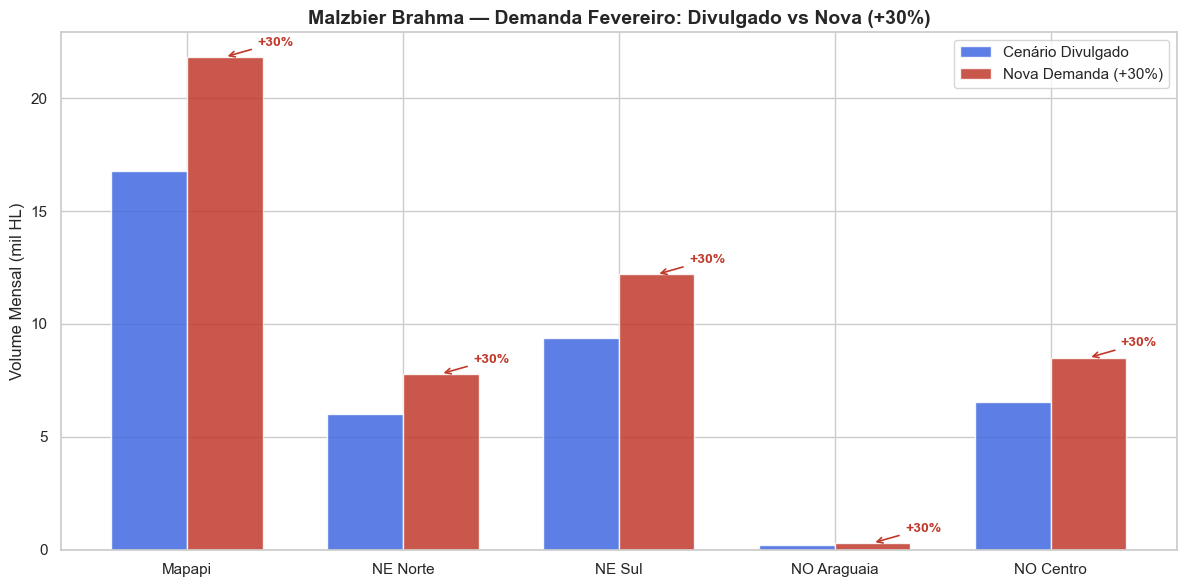

In [67]:
# Demanda Malzbier — Cenário Divulgado vs Nova Demanda (soma das 4 semanas)
geos = ['Mapapi', 'NE Norte', 'NE Sul', 'NO Araguaia', 'NO Centro']

# Cenário Divulgado (soma W0-W3)
div_mapapi = 4672.93 + 4835.70 + 3275.41 + 4003.52
div_ne_norte = 1516.73 + 1742.92 + 1313.77 + 1418.45
div_ne_sul = 2484.88 + 2705.85 + 1991.61 + 2197.89
div_araguaia = 60.66 + 71.44 + 48.40 + 50.69
div_no_centro = 1713.47 + 1894.68 + 1376.62 + 1558.40
divulgado = [div_mapapi, div_ne_norte, div_ne_sul, div_araguaia, div_no_centro]

# Nova Demanda (+30%)
novo_mapapi = 6074.80 + 6286.41 + 4258.03 + 5204.58
novo_ne_norte = 1971.75 + 2265.80 + 1707.90 + 1843.99
novo_ne_sul = 3230.35 + 3517.61 + 2589.09 + 2857.26
novo_araguaia = 78.86 + 92.87 + 62.92 + 65.89
novo_no_centro = 2227.52 + 2463.08 + 1789.61 + 2025.93
nova_dem = [novo_mapapi, novo_ne_norte, novo_ne_sul, novo_araguaia, novo_no_centro]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(geos))
w = 0.35

bars1 = ax.bar(x - w/2, [v/1000 for v in divulgado], w, label='Cenário Divulgado', color=AMBEV_BLUE, alpha=0.85)
bars2 = ax.bar(x + w/2, [v/1000 for v in nova_dem], w, label='Nova Demanda (+30%)', color=AMBEV_RED, alpha=0.85)

# Anotações de delta %
for i in range(len(geos)):
    delta = (nova_dem[i] - divulgado[i]) / divulgado[i] * 100
    mid_x = x[i] + w/2
    y_val = nova_dem[i] / 1000
    ax.annotate(f'+{delta:.0f}%', xy=(mid_x, y_val), xytext=(mid_x + 0.15, y_val + 0.5),
                fontsize=10, color=AMBEV_RED, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=AMBEV_RED, lw=1.2))

ax.set_xticks(x)
ax.set_xticklabels(geos)
ax.set_ylabel('Volume Mensal (mil HL)')
ax.set_title('Malzbier Brahma — Demanda Fevereiro: Divulgado vs Nova (+30%)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 8. Suficiência em Dias (DOI) — Cenário com Nova Demanda
Evolução da suficiência de estoque (dias de cobertura) ao longo das semanas de fevereiro para Malzbier Brahma. A linha vermelha indica o DOI mínimo de 12 dias exigido.

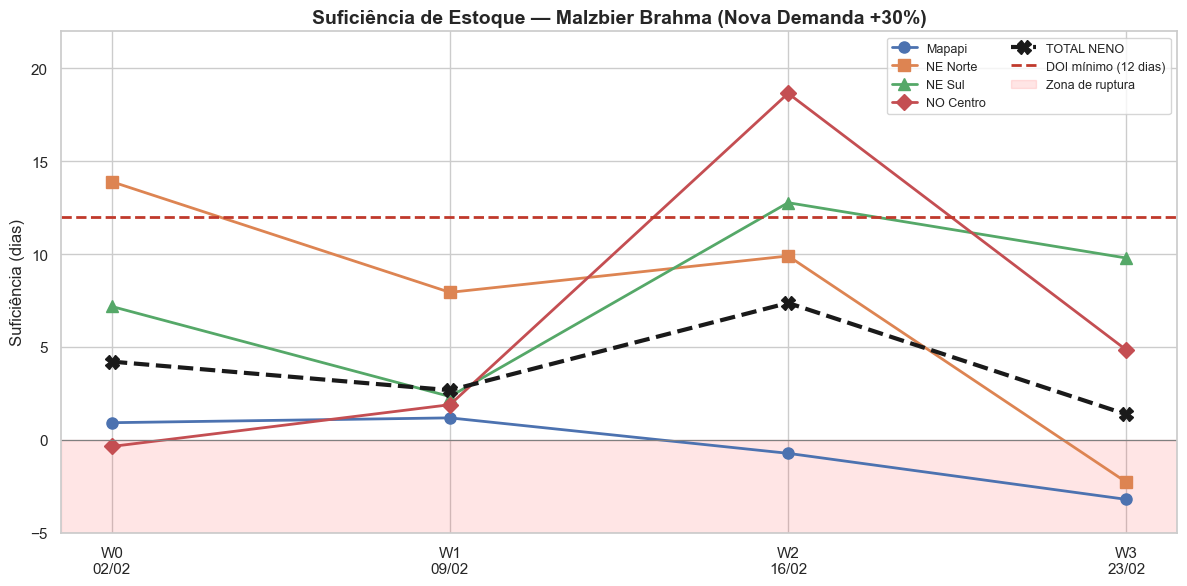

In [68]:
# Suficiência em dias — Malzbier (Cenário Nova Demanda)
semanas_label = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']

# Suficiência final por semana (Cenário Nova Demanda - Malzbier)
suf_mapapi    = [0.92, 1.18, -0.73, -3.21]
suf_ne_norte  = [13.90, 7.94, 9.90, -2.28]
suf_ne_sul    = [7.18, 2.33, 12.77, 9.79]
suf_no_centro = [-0.36, 1.89, 18.66, 4.84]
suf_total     = [4.21, 2.67, 7.37, 1.37]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(semanas_label, suf_mapapi, 'o-', label='Mapapi', linewidth=2, markersize=8)
ax.plot(semanas_label, suf_ne_norte, 's-', label='NE Norte', linewidth=2, markersize=8)
ax.plot(semanas_label, suf_ne_sul, '^-', label='NE Sul', linewidth=2, markersize=8)
ax.plot(semanas_label, suf_no_centro, 'D-', label='NO Centro', linewidth=2, markersize=8)
ax.plot(semanas_label, suf_total, 'X--', label='TOTAL NENO', linewidth=3, markersize=10, color=AMBEV_DARK)

# Linha de DOI mínimo
ax.axhline(y=12, color=AMBEV_RED, linestyle='--', linewidth=2, label='DOI mínimo (12 dias)')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)

# Zona de risco
ax.axhspan(-5, 0, alpha=0.1, color='red', label='Zona de ruptura')

ax.set_ylabel('Suficiência (dias)')
ax.set_title('Suficiência de Estoque — Malzbier Brahma (Nova Demanda +30%)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.set_ylim(-5, 22)
plt.tight_layout()
plt.show()


## 9. Suficiência em Dias — Goose Island Midway
Análise da cobertura de estoque para Goose Island, um SKU com restrição de capacidade de elaboração (líquido) em Pernambuco, dependente de transferências de SP.

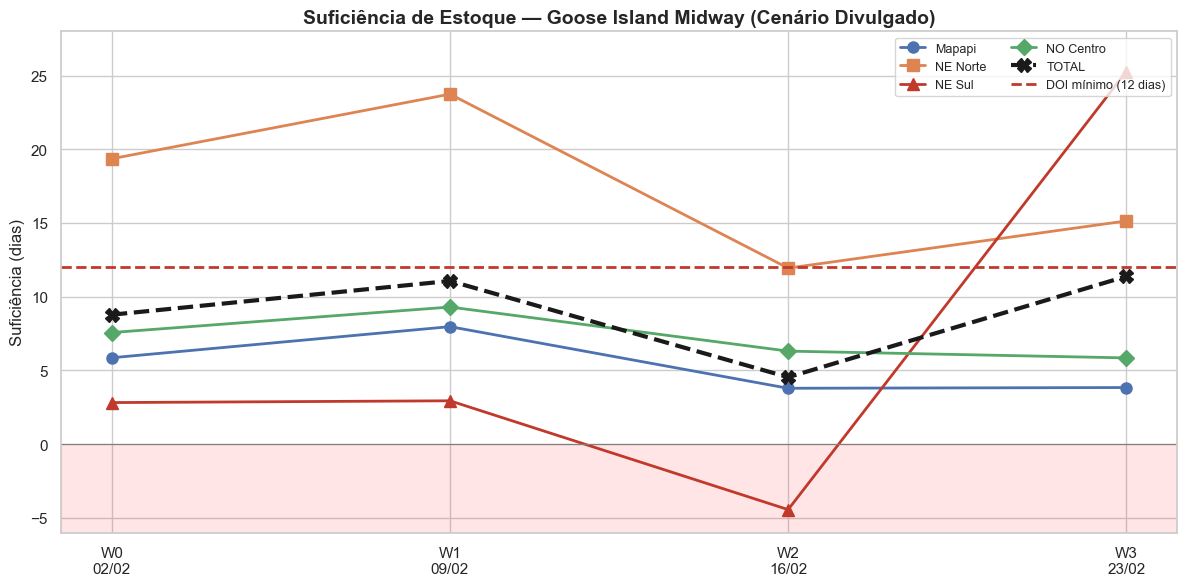

In [69]:
# Suficiência final por semana — Goose Island (Cenário Divulgado)
suf_goose_mapapi    = [5.86, 7.97, 3.79, 3.84]
suf_goose_ne_norte  = [19.36, 23.74, 11.94, 15.14]
suf_goose_ne_sul    = [2.82, 2.94, -4.44, 25.27]
suf_goose_no_centro = [7.57, 9.30, 6.31, 5.85]
suf_goose_total     = [8.78, 11.07, 4.54, 11.38]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(semanas_label, suf_goose_mapapi, 'o-', label='Mapapi', linewidth=2, markersize=8)
ax.plot(semanas_label, suf_goose_ne_norte, 's-', label='NE Norte', linewidth=2, markersize=8)
ax.plot(semanas_label, suf_goose_ne_sul, '^-', label='NE Sul', linewidth=2, markersize=8, color=AMBEV_RED)
ax.plot(semanas_label, suf_goose_no_centro, 'D-', label='NO Centro', linewidth=2, markersize=8)
ax.plot(semanas_label, suf_goose_total, 'X--', label='TOTAL', linewidth=3, markersize=10, color=AMBEV_DARK)

ax.axhline(y=12, color=AMBEV_RED, linestyle='--', linewidth=2, label='DOI mínimo (12 dias)')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax.axhspan(-6, 0, alpha=0.1, color='red')

ax.set_ylabel('Suficiência (dias)')
ax.set_title('Suficiência de Estoque — Goose Island Midway (Cenário Divulgado)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.set_ylim(-6, 28)
plt.tight_layout()
plt.show()


## 10. Transferências Programadas — Goose Island (SP → NE)
Mapa de calor das transferências semanais já planejadas de Goose Island Midway via cabotagem, mostrando os volumes por destino.

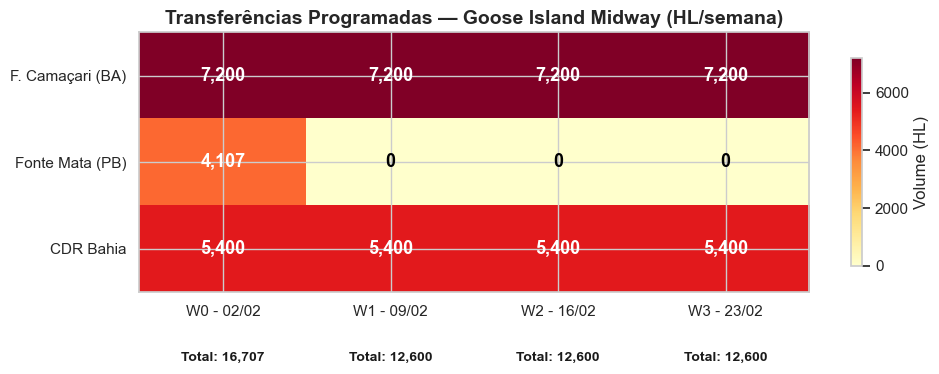

In [70]:
# Transferências programadas — Goose Island
destinos = ['F. Camaçari (BA)', 'Fonte Mata (PB)', 'CDR Bahia']
semanas_tr = ['W0 - 02/02', 'W1 - 09/02', 'W2 - 16/02', 'W3 - 23/02']
volumes = np.array([
    [7200, 7200, 7200, 7200],
    [4107, 0, 0, 0],
    [5400, 5400, 5400, 5400]
])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(volumes, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(4))
ax.set_xticklabels(semanas_tr)
ax.set_yticks(range(3))
ax.set_yticklabels(destinos)

# Anotações
for i in range(3):
    for j in range(4):
        color = 'white' if volumes[i,j] > 4000 else 'black'
        ax.text(j, i, f'{volumes[i,j]:,.0f}', ha='center', va='center', 
                fontsize=13, fontweight='bold', color=color)

# Total por semana
totais = volumes.sum(axis=0)
for j in range(4):
    ax.text(j, 3.3, f'Total: {totais[j]:,.0f}', ha='center', fontsize=10, fontweight='bold', color=AMBEV_DARK)

ax.set_title('Transferências Programadas — Goose Island Midway (HL/semana)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Volume (HL)')
plt.tight_layout()
plt.show()


## 11. Utilização da Capacidade Produtiva — Fevereiro 2026
Percentual de ocupação das linhas AQ541 e NS541 por semana. Importante para avaliar se há espaço para absorver a demanda adicional de Malzbier (+30%).

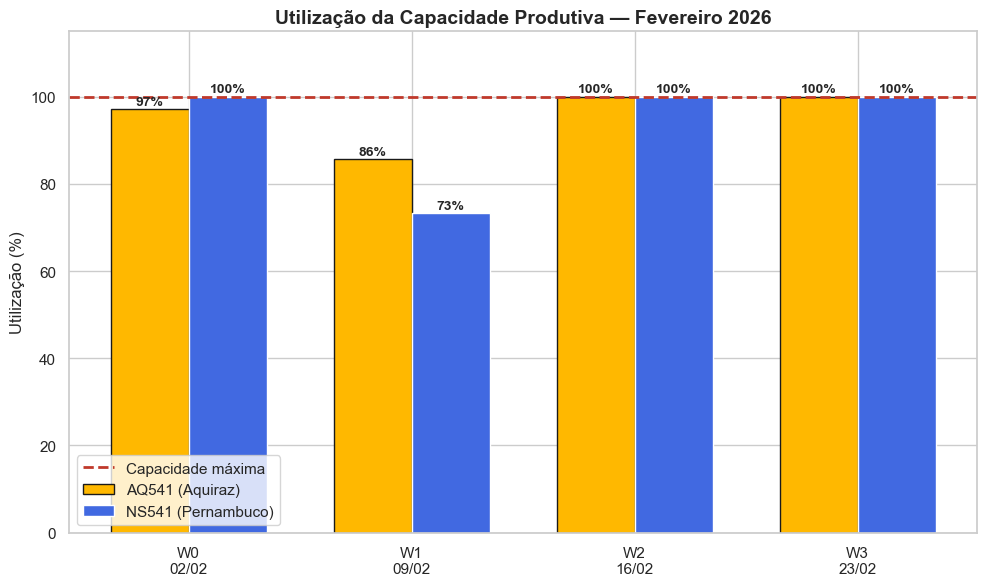

In [71]:
# Utilização de capacidade
cap_aq = 12600  # hl/semana
cap_ns = 27000

prod_aq = [12240, 10800, 12600, 12600]
prod_ns = [27000, 19800, 27000, 27000]

util_aq = [p/cap_aq*100 for p in prod_aq]
util_ns = [p/cap_ns*100 for p in prod_ns]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(4)
w = 0.35

bars1 = ax.bar(x - w/2, util_aq, w, label='AQ541 (Aquiraz)', color=AMBEV_YELLOW, edgecolor=AMBEV_DARK)
bars2 = ax.bar(x + w/2, util_ns, w, label='NS541 (Pernambuco)', color=AMBEV_BLUE)

ax.axhline(y=100, color=AMBEV_RED, linestyle='--', linewidth=2, label='Capacidade máxima')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02'])
ax.set_ylabel('Utilização (%)')
ax.set_ylim(0, 115)
ax.set_title('Utilização da Capacidade Produtiva — Fevereiro 2026', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 12. Estoque Final Total NENO — Malzbier: Divulgado vs Nova Demanda
Evolução do estoque final total de Malzbier no NENO ao longo de fevereiro, comparando os dois cenários. A queda drástica no cenário de nova demanda evidencia o risco de ruptura.

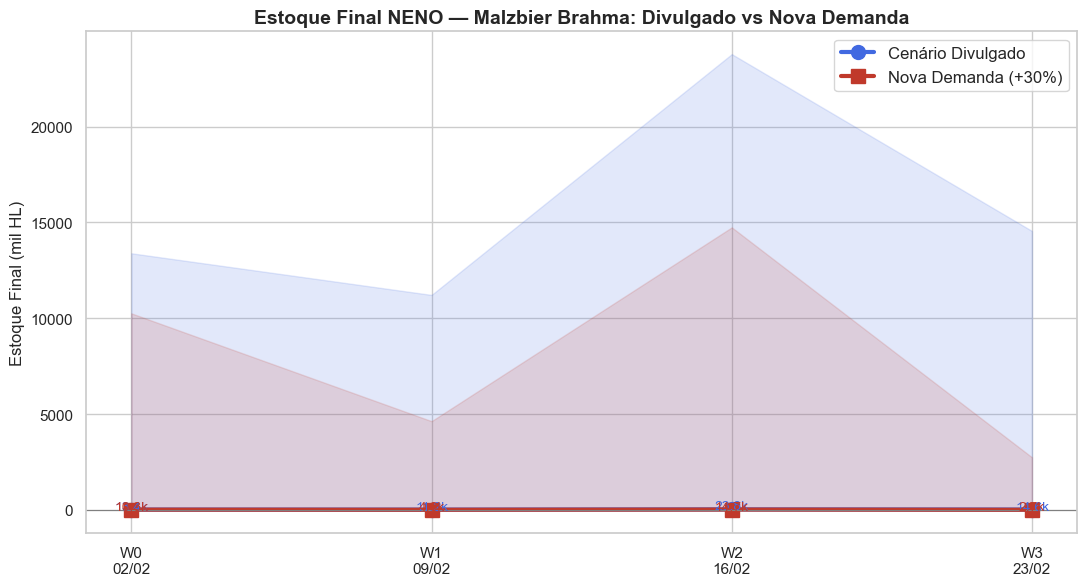

In [72]:
# Estoque Final Total — Malzbier (ambos cenários)
ef_div = [13386.98, 11213.56, 23780.15, 14551.28]
ef_novo = [10252.38, 4626.78, 14739.63, 2742.07]

fig, ax = plt.subplots(figsize=(11, 6))

ax.fill_between(range(4), ef_div, alpha=0.15, color=AMBEV_BLUE)
ax.fill_between(range(4), ef_novo, alpha=0.15, color=AMBEV_RED)

ax.plot(range(4), [v/1000 for v in ef_div], 'o-', label='Cenário Divulgado', 
        linewidth=3, markersize=10, color=AMBEV_BLUE)
ax.plot(range(4), [v/1000 for v in ef_novo], 's-', label='Nova Demanda (+30%)', 
        linewidth=3, markersize=10, color=AMBEV_RED)

for i in range(4):
    ax.text(i, ef_div[i]/1000 + 0.4, f'{ef_div[i]/1000:.1f}k', ha='center', fontsize=10, color=AMBEV_BLUE)
    ax.text(i, ef_novo[i]/1000 - 0.6, f'{ef_novo[i]/1000:.1f}k', ha='center', fontsize=10, color=AMBEV_RED)

ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax.set_xticks(range(4))
ax.set_xticklabels(['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02'])
ax.set_ylabel('Estoque Final (mil HL)')
ax.set_title('Estoque Final NENO — Malzbier Brahma: Divulgado vs Nova Demanda', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


## 13. Panorama Geral — Suficiência Final por SKU (W3)
Comparação da suficiência de estoque na última semana de fevereiro para cada SKU no cenário divulgado vs nova demanda. Mostra onde os riscos estão concentrados.

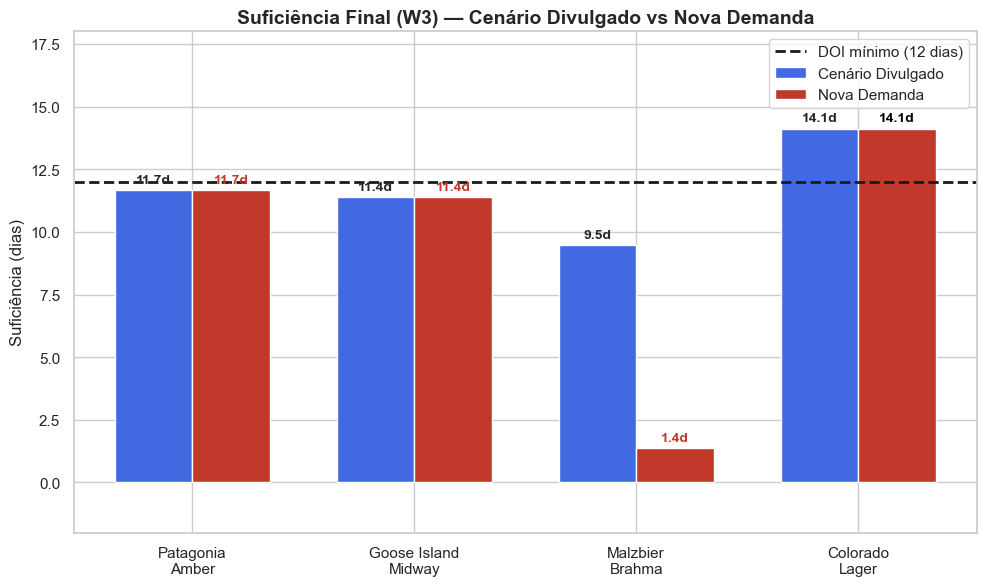

In [73]:
# Suficiência final W3 — Total NENO (ambos cenários)
skus = ['Patagonia\nAmber', 'Goose Island\nMidway', 'Malzbier\nBrahma', 'Colorado\nLager']

# Cenário Divulgado — Total Suf.f(d) W3
suf_div_w3 = [11.65, 11.38, 9.46, 14.12]

# Cenário Nova Demanda — Total Suf.f(d) W3
suf_novo_w3 = [11.65, 11.38, 1.37, 14.12]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(skus))
w = 0.35

ax.bar(x - w/2, suf_div_w3, w, label='Cenário Divulgado', color=AMBEV_BLUE, edgecolor='white')
ax.bar(x + w/2, suf_novo_w3, w, label='Nova Demanda', color=AMBEV_RED, edgecolor='white')

ax.axhline(y=12, color=AMBEV_DARK, linestyle='--', linewidth=2, label='DOI mínimo (12 dias)')

for i in range(len(skus)):
    ax.text(i - w/2, suf_div_w3[i] + 0.3, f'{suf_div_w3[i]:.1f}d', ha='center', fontsize=10, fontweight='bold')
    color = AMBEV_RED if suf_novo_w3[i] < 12 else 'black'
    ax.text(i + w/2, max(suf_novo_w3[i], 0) + 0.3, f'{suf_novo_w3[i]:.1f}d', ha='center', 
            fontsize=10, fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(skus, fontsize=11)
ax.set_ylabel('Suficiência (dias)')
ax.set_ylim(-2, 18)
ax.set_title('Suficiência Final (W3) — Cenário Divulgado vs Nova Demanda', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 14. Comparação de Modais Logísticos
Trade-off entre cabotagem e rodoviário para transferências SP → NE: o rodoviário é 60% mais caro e tem +5% de avarias, mas reduz o lead time de 25 para 6 dias.

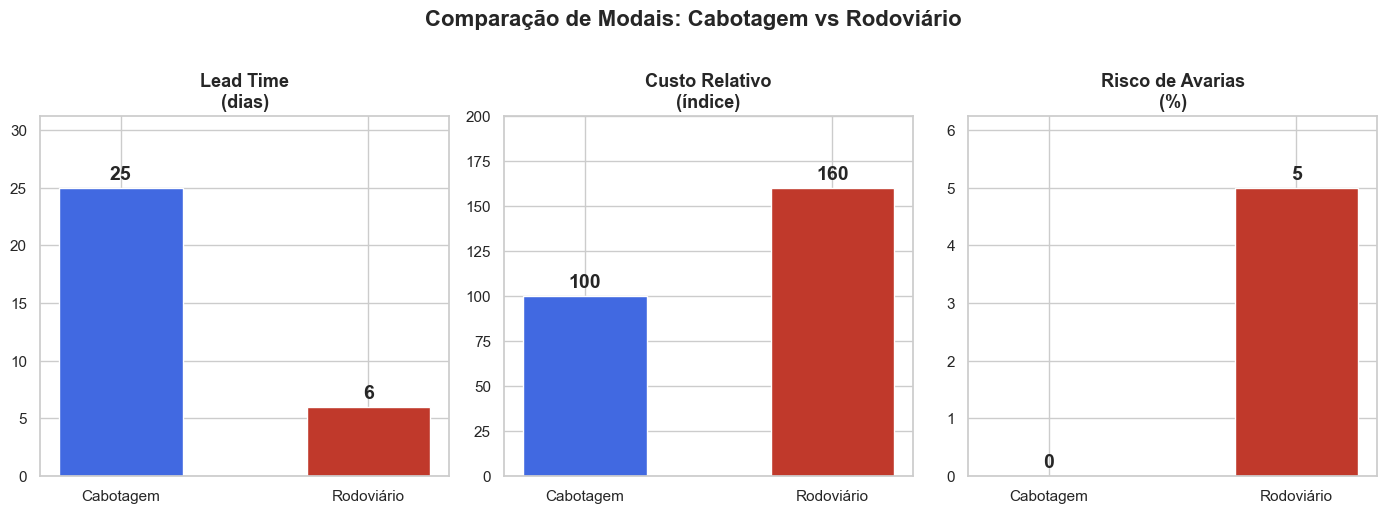

In [74]:
# Comparação de modais
categorias = ['Lead Time\n(dias)', 'Custo Relativo\n(índice)', 'Risco de Avarias\n(%)']

cabotagem = [25, 100, 0]
rodoviario = [6, 160, 5]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, (cat, cab, rod) in enumerate(zip(categorias, cabotagem, rodoviario)):
    ax = axes[i]
    bars = ax.bar(['Cabotagem', 'Rodoviário'], [cab, rod], 
                  color=[AMBEV_BLUE, AMBEV_RED], width=0.5, edgecolor='white')
    
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cab,rod)*0.03, 
                f'{bar.get_height():.0f}', ha='center', fontsize=14, fontweight='bold')
    
    ax.set_title(cat, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(cab, rod) * 1.25)

fig.suptitle('Comparação de Modais: Cabotagem vs Rodoviário', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Conclusões Visuais
Os gráficos acima evidenciam os principais pontos de atenção para o planejamento:

1. **Crescimento sustentado**: A demanda de LN no NENO cresce consistentemente ~8% ao ano.
2. **Capacidade no limite**: Ambas as linhas (AQ541 e NS541) operam próximas de 100% em várias semanas.
3. **Malzbier é o gargalo**: O aumento de 30% na demanda de Malzbier Brahma derruba a suficiência total para ~1,4 dias na W3 — muito abaixo dos 12 dias exigidos.
4. **Goose Island depende de SP**: Com produção travada no teto de líquido em PE, Goose Island depende integralmente de transferências de SP.
5. **Trade-off logístico**: Cabotagem é mais barata mas lenta (25 dias); rodoviário resolve urgências mas a 60% de custo adicional e +5% de avarias.
6. **BIAS de +9%**: O histórico de superestimação da demanda pelas GEOs deve ser considerado ao aceitar os novos volumes.


## 15. Evolução da Demanda por Cerveja — Cenário com Nova Demanda
Demanda total NENO (HL) de cada cerveja nas 4 semanas de fevereiro/2026, extraída diretamente da aba "Cenário com Nova Demanda".


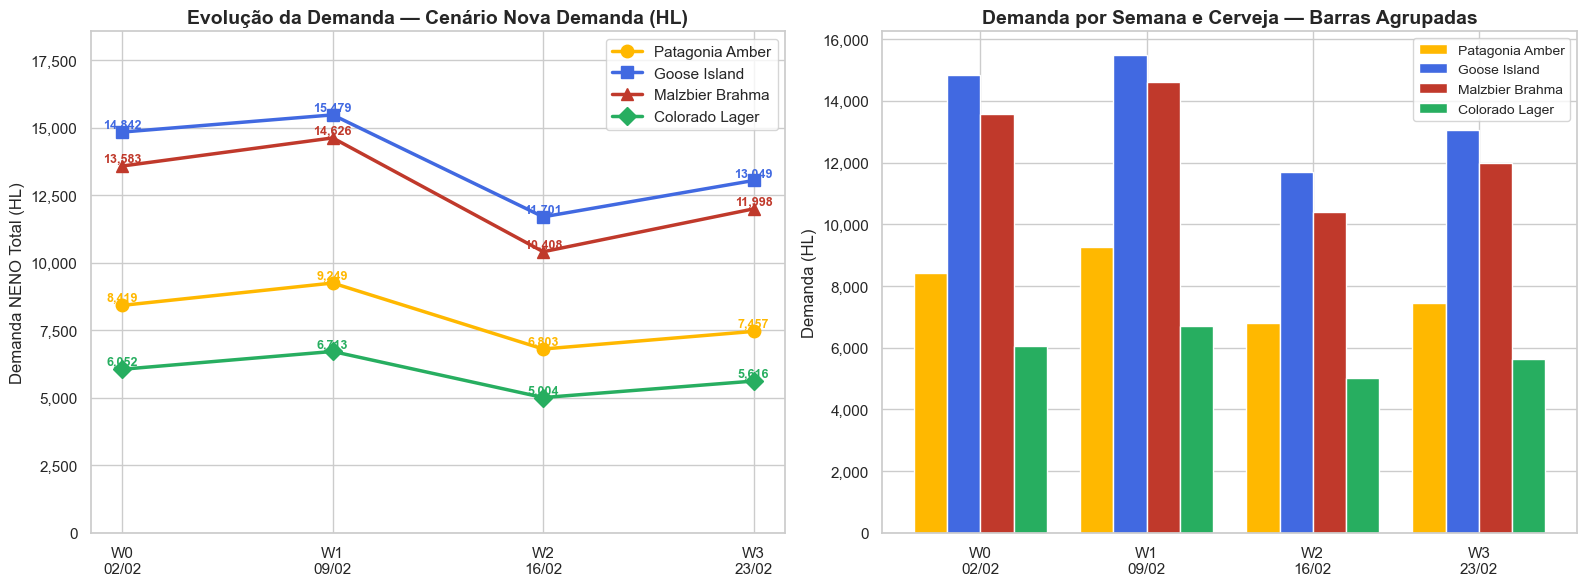

In [75]:
# Evolução da demanda das 4 cervejas — Cenário com Nova Demanda
import pandas as pd

file_path = '/Users/gustavopacheco/Downloads/Analise_LongNeck_OTIMIZADO.xlsx'
df = pd.read_excel(file_path, sheet_name='Cenário com Nova Demanda', header=None)

semanas = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']
dem_cols = [3, 16, 27, 38]  # Coluna Demanda de cada semana

cervejas = {
    'Patagonia Amber':  [df.iloc[9,  c] for c in dem_cols],
    'Goose Island':     [df.iloc[17, c] for c in dem_cols],
    'Malzbier Brahma':  [df.iloc[25, c] for c in dem_cols],
    'Colorado Lager':   [df.iloc[33, c] for c in dem_cols],
}

cores = {
    'Patagonia Amber': AMBEV_YELLOW,
    'Goose Island':    AMBEV_BLUE,
    'Malzbier Brahma': AMBEV_RED,
    'Colorado Lager':  AMBEV_GREEN,
}

markers = {'Patagonia Amber': 'o', 'Goose Island': 's', 'Malzbier Brahma': '^', 'Colorado Lager': 'D'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico de linhas ---
ax = axes[0]
for nome, demanda in cervejas.items():
    ax.plot(semanas, demanda, marker=markers[nome], linewidth=2.5, markersize=9,
            label=nome, color=cores[nome])
    for i, v in enumerate(demanda):
        ax.text(i, v + 150, f'{v:,.0f}', ha='center', fontsize=9,
                color=cores[nome], fontweight='bold')

ax.set_title('Evolução da Demanda — Cenário Nova Demanda (HL)', fontsize=14, fontweight='bold')
ax.set_ylabel('Demanda NENO Total (HL)')
ax.set_ylim(0, max(max(v) for v in cervejas.values()) * 1.2)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- Gráfico de barras agrupadas ---
ax2 = axes[1]
x = np.arange(len(semanas))
w = 0.2
for i, (nome, demanda) in enumerate(cervejas.items()):
    ax2.bar(x + i*w - 0.3, demanda, w, label=nome, color=cores[nome], edgecolor='white')

ax2.set_title('Demanda por Semana e Cerveja — Barras Agrupadas', fontsize=14, fontweight='bold')
ax2.set_ylabel('Demanda (HL)')
ax2.set_xticks(x)
ax2.set_xticklabels(semanas)
ax2.legend(fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()
